# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Tangaran, Grisby Paul James
- _Student No._: 2024-02777
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 Horner's Rule (Gezerlis Problem 2.11)

![Execution times and Absolute deviation of both function ](exectime-dev.png)

Figure 1. Comparison of execution time and numerical error deviation between naive polynomial evaluation and Horner's rule across polynomial degrees $n \in [1, 500]$.

The left graph illustrates execution time as a function of the number of coefficients ($n$). The naive evaluation (red) exhibits quadratic growth ($\mathcal{O}(n^2)$), with average execution time rising sharply toward 0.003 seconds at $n = 500$ due to redundant exponentiation loops. In contrast, Horner’s rule (blue) maintains a virtually flat, near-zero execution time across all degrees, confirming its linear time complexity ($\mathcal{O}(n)$) and superior operational efficiency.

The right graph displays the absolute deviation on a logarithmic scale. As the polynomial degree increases, the discrepancy between the two methods grows exponentially, surpassing $10^{130}$ near $n = 500$. This dramatic divergence highlights the severe accumulation of IEEE 754 floating-point rounding errors and numerical instability inherent in naive repeated multiplications. Horner's rule eliminates redundant exponentiation, preventing this massive error accumulation and ensuring numerical stability.

### Problem 2 Taylor Series Evaluation

![Execution times and Absolute deviation of both function ](taylor-numpy.png)

Figure 2. Comparison of Taylor series evaluation via Horner's rule against NumPy reference implementations for $e^x$ and $\sin(x)$ over $x \in [0, 10]$.

The plots compare library-free Taylor series approximations against NumPy reference functions (np.exp and np.sin). For $e^x$, Horner's rule rewrites the Taylor polynomial into nested linear operations, eliminating redundant power loops.

For $\sin(x)$, exponentiation cannot be completely avoided because higher-order polynomial terms inherently depend on powers of $x$. However, exponent operations are minimized by factoring out $x$ to express the series as $\sin(x) = x \cdot P(x^2)$. Computing $y = x^2$ just once allows Horner’s method to evaluate $P(y)$ sequentially, skipping missing even-degree terms entirely and avoiding explicit power calls (x**n).

Across $x \in [0, 10]$, the Taylor series curves (blue solid line) overlay NumPy's outputs (red dashed line) with no visible deviation. This confirms that combining Horner's rule with variable substitution yields numerical accuracy and stability matching optimized math libraries.

### Other comments
- I had a hard time understanding problem 1

---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [15]:
# code here
def eval_naive(coeffs, x):
    #Evaluate P(x) naively using explicit repeated multiplication.
    value = 0.0
    for i, coeff in enumerate(coeffs):
        power = 1.0
        for _ in range(i):
            power *= x # Recomputes power x^i from scratch
        value += coeff * power
    return value

def eval_horner(coeffs, x):
    #Evaluate P(x) using Horner's rule from right to left.
    value = 0.0

    for coeff in reversed(coeffs):
        value = value * x + coeff  # Single multiply-add step per term

    return value


Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [16]:
# Given test case from the problem.
coeffs = [(-11)**i for i in reversed(range(8))]
x = 11.01

naive_val = eval_naive(coeffs, x)
horner_val = eval_horner(coeffs, x)

print(f"Naive evaluation:    {naive_val}")
print(f"Horner's evaluation: {horner_val}")

absolute_error = abs(naive_val - horner_val)
print(f"Absolute difference: {absolute_error}")

Naive evaluation:    71056.02362163737
Horner's evaluation: 71056.02362163365
Absolute difference: 3.725290298461914e-09


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

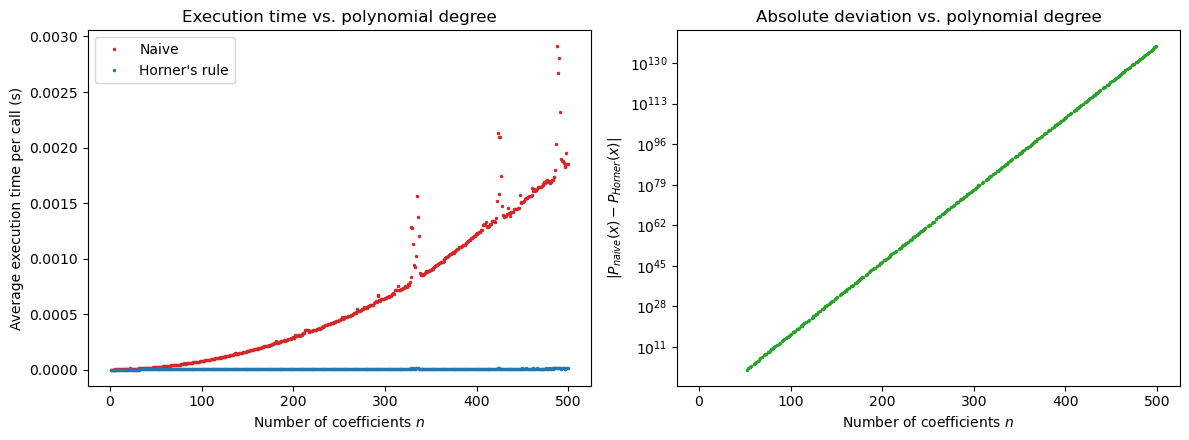

In [14]:
import time
import matplotlib.pyplot as plt

x_eval = 2.0   
degrees = range(1, 501)
naive_times = []
horner_times = []
deviations = []
n_repeats = 50  # repeat each call to get a stable timing measurement

for n in degrees:
    # Growing coefficient values to observe floating-point cancellation errors
    poly_coeffs = [float(k + 1) for k in range(n)] 

    # Time naive evaluation
    start = time.perf_counter()
    for _ in range(n_repeats):
        naive_val = eval_naive(poly_coeffs, x_eval)
    naive_times.append((time.perf_counter() - start) / n_repeats) # average time per call

    # Time Horner evaluation
    start = time.perf_counter()
    for _ in range(n_repeats):
        horner_val = eval_horner(poly_coeffs, x_eval)
    horner_times.append((time.perf_counter() - start) / n_repeats) # average time per call

    # Discrepancy between methods at degree n
    deviations.append(abs(naive_val - horner_val)) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot as individual dots using marker='.' and custom markersize
ax1.plot(degrees, naive_times, '.', label="Naive", color='tab:red', markersize=3)
ax1.plot(degrees, horner_times, '.', label="Horner's rule", color='tab:blue', markersize=3)
ax1.set_xlabel("Number of coefficients $n$")
ax1.set_ylabel("Average execution time per call (s)")
ax1.set_title("Execution time vs. polynomial degree")
ax1.legend()

ax2.plot(degrees, deviations, '.', color='tab:green', markersize=3)
ax2.set_xlabel("Number of coefficients $n$")
ax2.set_ylabel(r"$|P_{naive}(x) - P_{Horner}(x)|$")
ax2.set_title("Absolute deviation vs. polynomial degree")
ax2.set_yscale("log")
plt.tight_layout()
plt.savefig('exectime-dev.png')
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

* The code compares two ways to solve polynomial math problems to show which approach is faster and more accurate as the problems grow larger. The naive approach recalculates exponents repeatedly from scratch, whereas Horner's rule rewrites the equation into nested steps to reuse previous calculations. By using Horner's rule, the total number of math operations is drastically reduced, which speeds up processing time and prevents tiny computer rounding errors from compounding into big mistakes.
---

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

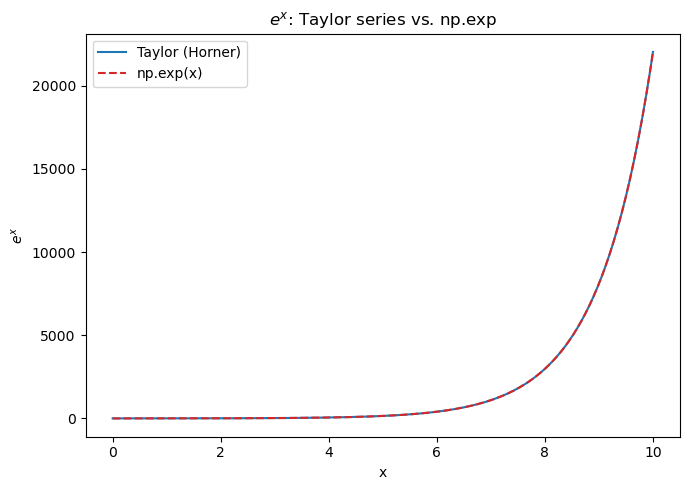

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def eval_horner(coeffs, x):
    # Evaluates polynomial P(x) using Horner's rule from highest to lowest degree
    value = 0.0
    for coeff in reversed(coeffs):
        value = value * x + coeff # Single multiply-add step per coefficient
    return value


def factorial(n):
    # Calculates n! iteratively without external libraries
    result = 1
    for k in range(2, n + 1):
        result *= k
    return result


def taylor_exp_coeffs(n_terms):
    #Return the first n Taylor coefficients of e^x.
    return [1 / factorial(i) for i in range(n_terms)]


def exp_horner(x, coeffs):
    #Evaluate the Taylor approximation of e^x using Horner's rule.
    return eval_horner(coeffs, x)


n_terms = 50
coeffs = taylor_exp_coeffs(n_terms)
x_values = np.linspace(0, 10, 400)

# Evaluate e^x using the Taylor series and Horner's rule.
exp_taylor = [exp_horner(x, coeffs) for x in x_values]
# Compute e^x using NumPy as the reference implementation.
exp_numpy = np.exp(x_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values, exp_taylor, label="Taylor (Horner)", color="tab:blue")
plt.plot(x_values, exp_numpy, "--", label="np.exp(x)", color="tab:red")

plt.title(r"$e^x$: Taylor series vs. np.exp")
plt.xlabel("x")
plt.ylabel("$e^x$")
plt.legend()
plt.savefig('exponential-func.png')
plt.tight_layout()
plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

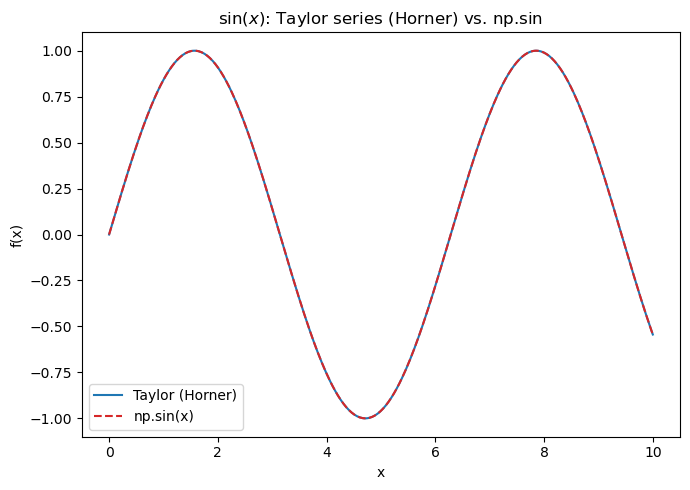

In [9]:

def taylor_sin_coeffs(n_terms):
    # Generates coefficients for sin(x) = x * g(x^2), where g(y) = sum_k ((-1)^k / (2k+1)!) y^k
    # incrementally computes sign and factorial to avoid power and factorial library calls
    coeffs = []
    sign = 1
    fact = 1

    for k in range(n_terms):
        coeffs.append(sign / fact)
        sign *= -1
        fact *= (2 * k + 2) * (2 * k + 3) # Updates (2k+1)! to (2k+3)! for next term
    return coeffs


def sin_horner(x, n_terms=30):
    # Evaluates sin(x) via Horner's rule on odd-power terms using y = x^2 substitution
    coeffs = taylor_sin_coeffs(n_terms)
    y = x * x  # Compute x^2 once to eliminate explicit power calculations
    return x * eval_horner(coeffs, y)  # Factor back the pulled-out x term


x_values = np.linspace(0, 10, 400)
sin_taylor = [sin_horner(x) for x in x_values]
sin_numpy = np.sin(x_values)


plt.figure(figsize=(7, 5))
plt.plot(x_values, sin_taylor, label="Taylor (Horner)", color="tab:blue")
plt.plot(x_values, sin_numpy, "--", label="np.sin(x)", color="tab:red")

plt.title(r"$\sin(x)$: Taylor series (Horner) vs. np.sin")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.savefig('sin-func.png')
plt.tight_layout()
plt.show()

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

* This script evaluates $e^x$ and $\sin(x)$ across $x \in [0, 10]$ using Taylor series approximations and compares them directly against NumPy's built-in functions. Horner's rule was used to replace redundant exponent calculations with simple multiply-add operations, alongside a $y = x^2$ substitution for $\sin(x)$ to eliminate missing even terms and minimize multiplications. The resulting plots demonstrate that the custom Taylor series implementation perfectly overlays `np.exp()` and `np.sin()`, proving that Horner's rule achieves accuracy and numerical stability matching optimized math libraries.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

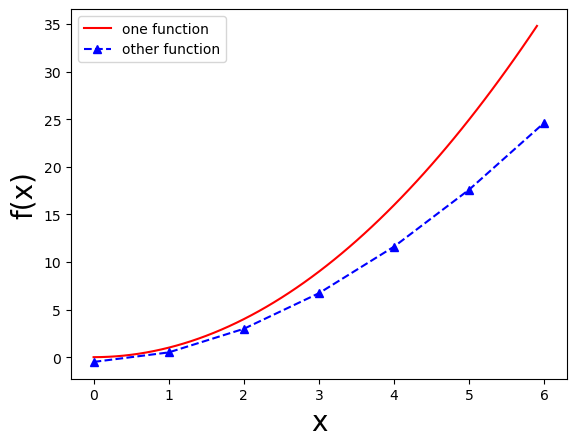

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

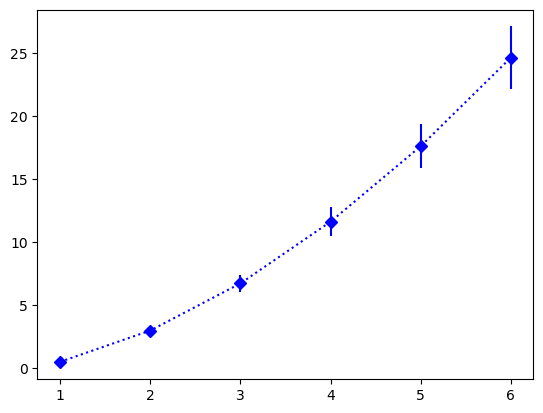

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])